# Transformers

Transformers are the architecture behind nearly every recent breakthrough in artificial intelligence — from machine translation and web search, to chatbots like ChatGPT, to protein-structure prediction and image generation. Since their introduction in the *"Attention Is All You Need"* paper, they have largely replaced the recurrent (RNN/LSTM) and convolutional architectures that previously dominated sequence modeling.

**Why did they take over?** Earlier sequence models read text one token at a time, which made them slow to train and prone to "forgetting" information from earlier in long sequences. Transformers instead use a mechanism called **self-attention**, which lets every token look at every other token directly and in parallel. This makes them dramatically faster to train on modern hardware (GPUs/TPUs) and far better at capturing long-range relationships in data.

**The core idea — attention.** Rather than compressing an entire input into a single fixed summary, a transformer learns, for each token, how much to "pay attention" to every other token. The word *"it"* in a sentence can learn to attend to the noun it refers to, and a word at the end of a paragraph can attend directly to a word at the beginning.

**A flexible architecture.** The original transformer pairs an **encoder** (which builds a rich, contextual understanding of the input) with a **decoder** (which generates an output sequence). In practice, this design is used in three main configurations, each suited to different tasks:

- **Encoder-only** (e.g., **BERT**) — best for *understanding* tasks like classification, search, and named-entity recognition.
- **Decoder-only** (e.g., **GPT**) — best for *generation* tasks like text completion and chat.
- **Encoder-decoder** (e.g., **T5**, **BART**, and the original Transformer) — best for *sequence-to-sequence* tasks like translation and summarization.

### What this notebook covers

This notebook builds up the Transformer and the model families built on it, with runnable **TensorFlow** and **PyTorch** examples at each stage:

1. **The Transformer** — self-attention, multi-head attention, positional encoding, and the full architecture built from scratch.
2. **Encoder-only models (BERT)** — built from scratch and used via pre-trained models.
3. **Decoder-only models (GPT)** — text generation with a pre-trained model.
4. **Encoder–decoder models** — sequence-to-sequence tasks like translation.

## Why Transformers?

Transformers mark a paradigm shift in sequence modeling by eliminating the need for recurrent architectures. Introduced in the paper "Attention is All You Need," transformers rely solely on attention mechanisms and feed-forward neural networks. This design enables the model to process entire sequences in parallel, vastly improving training efficiency and scalability, particularly for long sequences.

Traditional sequence models like RNNs or LSTMs process tokens sequentially, meaning that each token's representation depends on the previous ones. While effective for capturing temporal dependencies, this sequential nature makes training inefficient and limits the model's ability to capture long-range dependencies due to vanishing gradients.

Transformers address these challenges by:

- **Parallel Processing:**  
  Instead of processing tokens one at a time, transformers analyze the entire sequence simultaneously. This parallelism speeds up training on modern hardware (e.g., GPUs) and allows for more efficient use of computational resources.

- **Long-Range Dependency Modeling:**  
  With attention mechanisms, each token in a sequence can directly interact with every other token. This direct connectivity helps the model capture long-range dependencies that are often lost in RNNs.

- **Scalability:**  
  The architecture scales well with increasing amounts of data and longer sequences, making it suitable for large-scale natural language processing tasks and beyond.

![](https://aiml.com/wp-content/uploads/2023/09/Annotated-Transformers-Architecture.png)

## Core Building Blocks Of Transformers

Transformers are composed of several key components that work together to transform input sequences into meaningful outputs.

### Self-Attention

Self-attention is the central mechanism that allows transformers to weigh the importance of different tokens in a sequence relative to one another. The idea is that the meaning of a token usually depends on the other tokens around it — in *"the animal didn't cross the street because **it** was tired,"* the word *"it"* only makes sense once you connect it to *"animal."* Self-attention lets the model build each token's new representation as a **blend of all the other tokens**, weighted by how relevant each one is.

#### Key, Query, and Value

The mechanism is easiest to understand as a **soft dictionary lookup**. Imagine searching a library: you have a *request* for what you want, every book has a *label* you can match against, and each book has *contents* you actually take away. Self-attention gives every token all three roles at once:

- **Query (Q):** what this token is *looking for* in the other tokens (the search request).
- **Key (K):** what each token *offers* or advertises, so it can be matched against queries (the label).
- **Value (V):** the actual information a token *contributes* if it is attended to (the contents).

For an input matrix $X$ (with shape $T \times d_{\text{model}}$, where $T$ is the sequence length and $d_{\text{model}}$ is the embedding dimension), these vectors are computed as:

$$
Q = XW^Q, \quad K = XW^K, \quad V = XW^V
$$

- **Learned Projections:**
  The weight matrices $W^Q$, $W^K$, and $W^V$ are learned during training. Multiplying the embeddings $X$ by each one projects every token into a new subspace, producing three separate views of the same tokens. Because the projections are learned, the model *discovers* what makes a good "request," a good "label," and useful "contents" — they are not the raw embeddings, but transformations tuned to the attention task.

#### Scaled Dot-Product Attention

Once the queries, keys, and values are computed, the model decides how much each token should attend to every other token. This is the scaled dot-product attention:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

Working through it from the inside out:

- **Dot-Product ($QK^\top$):**
  Taking the dot product of a query with a key measures how aligned they are — a large value means "this key is a strong match for what the query wants." Computing $QK^\top$ does this for *every* query against *every* key at once, producing a $T \times T$ **score matrix** where entry $(i, j)$ is how much token $i$ should attend to token $j$.
- **Scaling Factor ($\tfrac{1}{\sqrt{d_k}}$):**
  When the key dimension $d_k$ is large, the dot products tend to grow large in magnitude simply because they sum over more terms. Very large values push the softmax into a near-flat, saturated region where gradients almost vanish, which stalls learning. Dividing by $\sqrt{d_k}$ keeps the scores at a stable scale so training stays well-behaved.
- **Softmax:**
  Applied across each row, softmax turns the raw scores into **attention weights** that are positive and sum to 1 — a probability distribution describing how token $i$ splits its attention over all tokens.
- **Weighted Sum ($\dots V$):**
  Finally those weights are used to average the value vectors. Each token's output is a weighted sum of the values, so tokens it attends to strongly contribute most. The result is a new representation of every token that has been **enriched with context** from the rest of the sequence.

### Multi-Head Attention

Instead of computing a single attention function, transformers use multi-head attention to capture information from multiple representation subspaces simultaneously. The intuition is that there is more than one kind of relationship worth tracking — one head might learn to link pronouns to the nouns they refer to, another might track verb–subject agreement, another nearby word order. Forcing a single attention pattern to capture all of these at once would be limiting, so the model runs several in parallel. Each "head" gets its own learned $W^Q$, $W^K$, $W^V$ projections and attends independently.

For each head $i$:

$$
\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

- **Multiple Heads:**
  Each head operates in its own lower-dimensional subspace and is free to specialize in a different aspect of the input.
- **Concatenation and Projection:**
  The outputs from all heads are concatenated back together and then mixed by a final output matrix $W^O$, which combines what the heads found into a single representation:

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O
$$

This lets the model integrate diverse, complementary information from many heads into one richer representation.

### Position-Wise Feed-Forward Networks

After the multi-head attention layer, each token's representation is processed independently through a feed-forward network. Where attention *mixes information across tokens*, this network *transforms each token on its own*. It is the same small two-layer network applied identically at every position — two linear transformations with a non-linear activation (typically ReLU) in between:

$$
\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2
$$

Reading it left to right: $xW_1 + b_1$ projects the token *up* to a larger hidden dimension, $\max(0, \cdot)$ is the ReLU that injects non-linearity (without it the two linear layers would collapse into one), and $W_2$ projects back *down* to $d_{\text{model}}$.

- **Independent Processing:**
  Because it acts on one token at a time, the FFN cannot move information between positions — that job belongs to attention. The two layers alternate: attention gathers context, then the FFN digests it.
- **Enhancing Capacity:**
  The expand-then-contract shape gives the model room to compute richer, non-linear features at each position, increasing its representational power.

### Positional Encoding

Self-attention treats its input as an unordered **set** — if you shuffled the tokens, the attention computation would give the same answers, just shuffled. That means the model has no inherent sense of *order*, even though word order obviously carries meaning. Positional encodings fix this by adding a position-dependent signal to each token embedding. A common choice uses sine and cosine functions of varying frequencies:

$$
\text{PE}_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$

$$
\text{PE}_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$

- **Encoding Positions:**
  Here $pos$ is the token's position in the sequence and $i$ indexes the embedding dimension. Each dimension oscillates at a different frequency — low dimensions change slowly across positions, high dimensions change quickly — so every position gets a unique, smoothly varying "fingerprint." A useful side effect of using sinusoids is that the encoding for one position can be written as a linear function of another, which makes it easy for the model to reason about *relative* offsets like "three tokens back."
- **Incorporation into Embeddings:**
  These encodings are simply **added** to the token embeddings before the first transformer layer, so each token carries both *what* it is and *where* it sits in the sequence.

### Seeing Attention in Action

The math above is easier to believe once you can *see* it. The cell below implements scaled dot-product attention exactly as written — $\text{softmax}\!\left(\tfrac{QK^\top}{\sqrt{d_k}}\right)V$ — on a short sentence, then plots the resulting $T \times T$ attention-weight matrix as a heatmap.

Read it **row by row**: row $i$ shows how token $i$ (the *query*) spreads its attention across every token (the *keys*), and each row sums to 1. We use random, untrained projections here, so the *pattern* is arbitrary — the point is the **mechanism and shape**, not linguistic meaning. In a trained model these weights line up with real relationships (as you saw, *"it"* attending to *"animal"*).

Attention weight matrix (each row sums to 1):

[[0.   0.   0.33 0.   0.67 0.  ]
 [0.   1.   0.   0.   0.   0.  ]
 [0.   0.   1.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.  ]
 [0.   0.   1.   0.   0.   0.  ]
 [0.03 0.   0.   0.   0.   0.97]]

Row sums: [1. 1. 1. 1. 1. 1.]


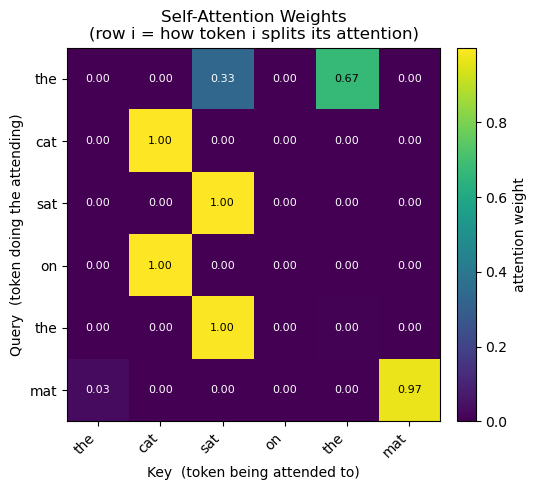

In [1]:
import os, warnings
from tqdm import TqdmWarning
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=TqdmWarning)   # text progress bars (no ipywidgets needed)
warnings.filterwarnings("ignore", message=".*enable_nested_tensor.*")
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

np.random.seed(0)

# A short example sentence; we treat each word as a single token.
sentence = "the cat sat on the mat"
tokens = sentence.split()
T = len(tokens)     # sequence length
d_model = 16        # embedding dimension
d_k = 16            # query/key dimension

# Random stand-in embeddings and projections (an UNTRAINED model: we only
# want to see the mechanism, so W^Q, W^K, W^V are random rather than learned).
X   = np.random.randn(T, d_model)
W_Q = np.random.randn(d_model, d_k)
W_K = np.random.randn(d_model, d_k)
W_V = np.random.randn(d_model, d_k)

# Project the embeddings into queries, keys, and values:  Q = X W^Q, etc.
Q = X @ W_Q
K = X @ W_K
V = X @ W_V

# Scaled dot-product scores -> a (T, T) matrix of all pairwise query-key matches
scores = (Q @ K.T) / np.sqrt(d_k)

# Row-wise softmax turns each row into attention weights that sum to 1
def softmax_rows(M):
    M = M - M.max(axis=1, keepdims=True)   # numerical stability
    e = np.exp(M)
    return e / e.sum(axis=1, keepdims=True)

attn = softmax_rows(scores)   # (T, T) attention weights
output = attn @ V             # (T, d_k) context-enriched token representations

print("Attention weight matrix (each row sums to 1):\n")
print(np.round(attn, 2))
print("\nRow sums:", np.round(attn.sum(axis=1), 3))

# Plot the attention weights as a heatmap
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(attn, cmap="viridis", vmin=0, vmax=attn.max())

ax.set_xticks(range(T)); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticks(range(T)); ax.set_yticklabels(tokens)
ax.set_xlabel("Key  (token being attended to)")
ax.set_ylabel("Query  (token doing the attending)")
ax.set_title("Self-Attention Weights\n(row i = how token i splits its attention)")

# Annotate each cell with its weight
for i in range(T):
    for j in range(T):
        ax.text(j, i, f"{attn[i, j]:.2f}", ha="center", va="center",
                color="white" if attn[i, j] < 0.5 * attn.max() else "black", fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="attention weight")
plt.tight_layout()
plt.show()


## Simple Transformer Examples
### TensorFlow

In [2]:
import tensorflow as tf
import numpy as np
import math

#### Positional Encoding

In [3]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, position, d_model):
        """
        Create sinusoidal positional encodings.
        Args:
            position: Maximum position (sequence length).
            d_model: Dimensionality of the embeddings.
        """
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(position, d_model)
    
    def get_angles(self, pos, i, d_model):
        angle_rates = 1 / (10000 ** (2 * (i // 2) / tf.cast(d_model, tf.float32)))
        return pos * angle_rates
    
    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(
            tf.range(position, dtype=tf.float32)[:, tf.newaxis],
            tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],
            d_model)
        
        # Apply sin to even indices; cos to odd indices
        sines = tf.math.sin(angle_rads[:, 0::2])
        cosines = tf.math.cos(angle_rads[:, 1::2])
        
        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = pos_encoding[tf.newaxis, ...]  # Shape: (1, position, d_model)
        return tf.cast(pos_encoding, tf.float32)
    
    def call(self, inputs):
        """
        Add positional encodings to the input embeddings.
        Args:
            inputs: Tensor of shape (batch_size, seq_len, d_model)
        Returns:
            Tensor with positional encodings added.
        """
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

#### Building The Transformer Model

In [4]:
class Transformer(tf.keras.Model):
    def __init__(self, vocab_size, d_model, num_heads, dff, num_layers, maximum_position_encoding, dropout_rate=0.1):
        """
        A simple transformer for sequence-to-sequence tasks.
        Args:
            vocab_size: Vocabulary size (for both source and target).
            d_model: Dimensionality of the embeddings and transformer model.
            num_heads: Number of attention heads.
            dff: Dimensionality of the feed-forward network.
            num_layers: Number of encoder and decoder layers.
            maximum_position_encoding: Maximum sequence length.
            dropout_rate: Dropout rate.
        """
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.num_layers = num_layers

        # Embedding layer and positional encoding for both source and target
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(maximum_position_encoding, d_model)
        
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        
        # Encoder: stack of multi-head attention and feed-forward networks
        self.enc_layers = [tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model) 
                           for _ in range(num_layers)]
        self.ffn_layers_enc = [tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ]) for _ in range(num_layers)]
        
        # Decoder: each layer performs self-attention, cross-attention, and feed-forward
        self.dec_layers = [tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model) 
                           for _ in range(num_layers)]
        self.ffn_layers_dec = [tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ]) for _ in range(num_layers)]
        
        # Final dense layer to project the decoder output to the vocabulary space
        self.final_layer = tf.keras.layers.Dense(vocab_size)
    
    def call(self, src, tgt, training):
        """
        Forward pass of the transformer.
        Args:
            src: Source sequence tensor of shape (batch, src_seq_len).
            tgt: Target sequence tensor of shape (batch, tgt_seq_len).
            training: Boolean flag for training mode.
        Returns:
            Output logits of shape (batch, tgt_seq_len, vocab_size).
        """
        # Embedding and positional encoding for source
        src_emb = self.embedding(src)  # (batch, src_seq_len, d_model)
        src_emb *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        src_emb = self.pos_encoding(src_emb)
        src_emb = self.dropout(src_emb, training=training)
        
        # Pass through encoder layers
        enc_output = src_emb
        for i in range(self.num_layers):
            # Self-attention: keys, queries, and values are all the encoder output
            attn_output = self.enc_layers[i](query=enc_output, value=enc_output, key=enc_output)
            attn_output = self.dropout(attn_output, training=training)
            # Residual connection and layer normalization
            enc_output = tf.keras.layers.LayerNormalization(epsilon=1e-6)(enc_output + attn_output)
            
            # Feed-forward network with residual connection and layer normalization
            ffn_output = self.ffn_layers_enc[i](enc_output)
            ffn_output = self.dropout(ffn_output, training=training)
            enc_output = tf.keras.layers.LayerNormalization(epsilon=1e-6)(enc_output + ffn_output)
        
        # Embedding and positional encoding for target
        tgt_emb = self.embedding(tgt)  # (batch, tgt_seq_len, d_model)
        tgt_emb *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        tgt_emb = self.pos_encoding(tgt_emb)
        tgt_emb = self.dropout(tgt_emb, training=training)
        
        # Pass through decoder layers
        dec_output = tgt_emb
        for i in range(self.num_layers):
            # Masked self-attention on target: the causal mask stops each position
            # from attending to future target tokens (so the model can't "cheat").
            attn1 = self.dec_layers[i](query=dec_output, value=dec_output, key=dec_output,
                                       use_causal_mask=True)
            attn1 = self.dropout(attn1, training=training)
            dec_output = tf.keras.layers.LayerNormalization(epsilon=1e-6)(dec_output + attn1)
            
            # Cross-attention: target attends to encoder output
            attn2 = self.dec_layers[i](query=dec_output, value=enc_output, key=enc_output)
            attn2 = self.dropout(attn2, training=training)
            dec_output = tf.keras.layers.LayerNormalization(epsilon=1e-6)(dec_output + attn2)
            
            # Feed-forward network with residual connection and layer normalization
            ffn_output = self.ffn_layers_dec[i](dec_output)
            ffn_output = self.dropout(ffn_output, training=training)
            dec_output = tf.keras.layers.LayerNormalization(epsilon=1e-6)(dec_output + ffn_output)
        
        # Final projection to vocabulary size
        final_output = self.final_layer(dec_output)  # (batch, tgt_seq_len, vocab_size)
        return final_output

#### Example Usage

The cell below trains this transformer on a small synthetic **copy task** — the model must reproduce its input sequence — for a few hundred epochs. Instead of printing a single, meaningless loss value, it shows the loss going *down*, the held-out **token accuracy**, and a sample **prediction next to the target**, so you can confirm the architecture actually *learns* (not just that it runs). Real models use far larger vocabularies and datasets.

In [5]:
vocab_size = 20            # small vocab so the toy task converges quickly
d_model = 128
num_heads = 4
dff = 512
num_layers = 2
maximum_position_encoding = 100
dropout_rate = 0.1
batch_size = 32
seq_len = 8
BOS = 0                    # token id 0 is reserved as the decoder "start" token
num_epochs = 300

tf.random.set_seed(0)

def make_batch():
    # Source tokens drawn from [1, vocab_size); the target is a copy of the source.
    src = tf.random.uniform((batch_size, seq_len), minval=1, maxval=vocab_size, dtype=tf.int32)
    tgt = src                                              # copy task: output == input
    # Teacher forcing: the decoder input is the target shifted right, prefixed with BOS.
    bos = tf.fill((batch_size, 1), BOS)
    dec_in = tf.concat([bos, tgt[:, :-1]], axis=1)         # (batch, seq_len)
    return src, dec_in, tgt

transformer = Transformer(vocab_size, d_model, num_heads, dff, num_layers,
                          maximum_position_encoding, dropout_rate)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# --- Short training loop (a fresh random batch each epoch) ---
for epoch in range(1, num_epochs + 1):
    src, dec_in, labels = make_batch()
    with tf.GradientTape() as tape:
        logits = transformer(src, dec_in, training=True)   # (batch, seq_len, vocab_size)
        loss = loss_object(labels, logits)
    grads = tape.gradient(loss, transformer.trainable_variables)
    optimizer.apply_gradients(zip(grads, transformer.trainable_variables))
    if epoch == 1 or epoch % 50 == 0:
        print(f"epoch {epoch:4d}  loss {loss.numpy():.4f}")

# --- Evaluate on a fresh, unseen batch ---
src, dec_in, labels = make_batch()
logits = transformer(src, dec_in, training=False)
preds = tf.argmax(logits, axis=-1, output_type=tf.int32)   # (batch, seq_len)
accuracy = tf.reduce_mean(tf.cast(preds == labels, tf.float32)).numpy()

print(f"\nHeld-out token accuracy: {accuracy * 100:.1f}%")
print("Source / target :", labels[0].numpy().tolist())
print("Model prediction:", preds[0].numpy().tolist())

epoch    1  loss 3.8586
epoch   50  loss 2.9879
epoch  100  loss 1.5726
epoch  150  loss 0.2493
epoch  200  loss 0.0596
epoch  250  loss 0.0946
epoch  300  loss 0.0383

Held-out token accuracy: 98.4%
Source / target : [19, 3, 4, 15, 13, 4, 11, 5]
Model prediction: [19, 3, 4, 15, 13, 4, 11, 5]


### PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import math

#### Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        """
        Implements the sinusoidal positional encoding function.
        Args:
            d_model: the embedding dimension.
            dropout: dropout rate.
            max_len: maximum length of sequences.
        """
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Create a long enough PEs matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # Compute the positional encodings once in log space.
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)  # Even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # Odd indices
        pe = pe.unsqueeze(1)  # Shape: (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor of shape (seq_len, batch_size, d_model)
        Returns:
            Tensor with positional encodings added.
        """
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

#### Defining The Transformer Model

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, model_dim, num_heads, num_encoder_layers, 
                 num_decoder_layers, ff_dim, dropout=0.1):
        """
        Args:
            vocab_size: Size of the vocabulary (for both src and tgt).
            model_dim: Dimensionality of the embeddings and transformer.
            num_heads: Number of attention heads.
            num_encoder_layers: Number of encoder layers.
            num_decoder_layers: Number of decoder layers.
            ff_dim: Dimensionality of the feed-forward network.
            dropout: Dropout rate.
        """
        super(TransformerModel, self).__init__()
        self.model_dim = model_dim
        
        # Embedding layers for input tokens
        self.embedding = nn.Embedding(vocab_size, model_dim)
        # Positional encoding to inject sequence order information
        self.pos_encoder = PositionalEncoding(model_dim, dropout)
        # PyTorch's built-in Transformer module
        self.transformer = nn.Transformer(d_model=model_dim, nhead=num_heads,
                                          num_encoder_layers=num_encoder_layers,
                                          num_decoder_layers=num_decoder_layers,
                                          dim_feedforward=ff_dim,
                                          dropout=dropout)
        # Final linear layer to project the transformer output to vocab size
        self.fc_out = nn.Linear(model_dim, vocab_size)
    
    def generate_square_subsequent_mask(self, sz):
        """
        Generate a square mask for the sequence. The masked positions are filled with float('-inf').
        Args:
            sz: Size of the mask (typically the target sequence length)
        Returns:
            A tensor mask of shape (sz, sz)
        """
        mask = torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)
        return mask

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        """
        Args:
            src: Source sequence tensor of shape (src_seq_len, batch_size)
            tgt: Target sequence tensor of shape (tgt_seq_len, batch_size)
            src_mask: Optional mask for the source sequence.
            tgt_mask: Optional mask for the target sequence.
        Returns:
            Output logits of shape (tgt_seq_len, batch_size, vocab_size)
        """
        # Embed the input tokens and scale them
        src = self.embedding(src) * math.sqrt(self.model_dim)
        src = self.pos_encoder(src)
        tgt = self.embedding(tgt) * math.sqrt(self.model_dim)
        tgt = self.pos_encoder(tgt)
        
        # Pass through the transformer
        output = self.transformer(src, tgt, src_mask=src_mask, tgt_mask=tgt_mask)
        output = self.fc_out(output)
        return output

#### Example Usage

As with the TensorFlow version, the cell below trains this model on a small synthetic **copy task** and then reports the loss trajectory, held-out **token accuracy**, and a sample **prediction vs. target** — a more informative check than a single loss value.

In [ ]:
# Rather than a single loss value on random data, train the model on a tiny,
# *learnable* "copy" task (output == input), then inspect its predictions
# and token accuracy.

vocab_size = 10            # small vocab so the toy task converges quickly
model_dim = 64             # lighter than 512 so this trains fast on CPU
num_heads = 4
num_encoder_layers = 2
num_decoder_layers = 2
ff_dim = 128
dropout = 0.0             # turn dropout OFF: on a tiny toy task it just slows learning
batch_size = 32
seq_len = 5
BOS = 0                    # token id 0 is reserved as the decoder "start" token
num_epochs = 2000
peak_lr = 1e-3
warmup_epochs = 100       # post-norm Transformers train poorly without a warmup

torch.manual_seed(0)

def make_batch():
    # This model is NOT batch_first, so tensors are shaped (seq_len, batch).
    src = torch.randint(1, vocab_size, (seq_len, batch_size))   # tokens in [1, vocab)
    tgt = src.clone()                                          # copy task: output == input
    # Teacher forcing: decoder input = target shifted right, prefixed with BOS.
    bos = torch.full((1, batch_size), BOS, dtype=torch.long)
    dec_in = torch.cat([bos, tgt[:-1, :]], dim=0)             # (seq_len, batch)
    return src, dec_in, tgt

model = TransformerModel(vocab_size, model_dim, num_heads, num_encoder_layers,
                         num_decoder_layers, ff_dim, dropout)
# Causal mask so decoder position i cannot peek at future target tokens.
tgt_mask = model.generate_square_subsequent_mask(seq_len)
optimizer = optim.Adam(model.parameters(), lr=peak_lr)
criterion = nn.CrossEntropyLoss()

# Linear learning-rate warmup, then constant.
def lr_for(epoch):
    return peak_lr * min(1.0, epoch / warmup_epochs)

# --- Short training loop (a fresh random batch each epoch) ---
model.train()
for epoch in range(1, num_epochs + 1):
    for group in optimizer.param_groups:
        group["lr"] = lr_for(epoch)
    src, dec_in, labels = make_batch()
    optimizer.zero_grad()
    output = model(src, dec_in, src_mask=None, tgt_mask=tgt_mask)  # (seq_len, batch, vocab)
    loss = criterion(output.view(-1, vocab_size), labels.view(-1))
    loss.backward()
    optimizer.step()
    if epoch == 1 or epoch % 250 == 0:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

# --- Evaluate on a fresh, unseen batch ---
model.eval()
with torch.no_grad():
    src, dec_in, labels = make_batch()
    output = model(src, dec_in, src_mask=None, tgt_mask=tgt_mask)
    preds = output.argmax(dim=-1)                              # (seq_len, batch)
    accuracy = (preds == labels).float().mean().item()

print(f"\nHeld-out token accuracy: {accuracy * 100:.1f}%")
# Show one example (column 0), since tensors are (seq_len, batch).
print("Source / target :", labels[:, 0].tolist())
print("Model prediction:", preds[:, 0].tolist())

## Real-World Example: Using Pre-Trained Models

Building a transformer from scratch is great for understanding *how* one works, but in practice you rarely start from zero. The Hugging Face `transformers` library gives you access to thousands of **pre-trained models** that you can download and run in just a few lines of code — many of them the same models used in production systems today.

The examples below use **MarianMT**, a family of open-source neural machine translation models, to translate English into German. We show two equivalent ways to load and run it: with the generic **`Auto` classes** (the recommended approach) and with the **model-specific classes**. The model and its tokenizer are downloaded automatically the first time you run a cell.

### Using the `Auto` Classes (Recommended)

The `Auto*` classes inspect the model name and load the correct architecture for you, so the same few lines work for almost any sequence-to-sequence model on the Hugging Face Hub — to use a different model, you only change `model_name`.

In [6]:
# MarianMT's tokenizer relies on the SentencePiece library (sacremoses silences a warning)
%pip install -q sentencepiece sacremoses

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Specify the model for English-to-German translation
model_name = "Helsinki-NLP/opus-mt-en-de"

# The Auto classes load the matching tokenizer and model architecture automatically
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Input text
text = "The weather is nice today, so let's go for a walk in the park."

# Tokenize, generate the translation, then decode the tokens back to text
inputs = tokenizer(text, return_tensors="pt", padding=True)
translated_tokens = model.generate(**inputs)
translated_text = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)

print("Source text:    ", text)
print("Translated text:", translated_text)


Note: you may need to restart the kernel to use updated packages.


Loading weights: 100%|█████████████████████| 258/258 [00:00<00:00, 84173.18it/s]


Source text:     The weather is nice today, so let's go for a walk in the park.
Translated text: Das Wetter ist heute schön, also machen wir einen Spaziergang im Park.


### Using Model-Specific Classes

You can also import the classes for a specific model family directly. This is more explicit and behaves identically — for this model, `AutoModelForSeq2SeqLM` simply resolves to `MarianMTModel` under the hood.

In [7]:
from transformers import MarianMTModel, MarianTokenizer

# Specify the model for English-to-German translation
model_name = "Helsinki-NLP/opus-mt-en-de"

# Load pre-trained model and tokenizer
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

# Input text
text = "Where is the nearest train station?"

# Tokenize and generate translation
inputs = tokenizer(text, return_tensors="pt", padding=True)
translated_tokens = model.generate(**inputs)
translated_text = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)

print("Source text:    ", text)
print("Translated text:", translated_text)


Loading weights: 100%|████████████████████| 258/258 [00:00<00:00, 116936.51it/s]


Source text:     Where is the nearest train station?
Translated text: Wo ist der nächste Bahnhof?


## Real-World Example Without Pre-Trained Models

Below are examples for both TensorFlow and PyTorch that not only build a model using framework‑specific solutions but also include a simple (toy) inference routine that accepts an English phrase and produces a German translation. 

Keep in mind:
- These examples assume you have already trained your model and built tokenization routines.
- The tokenizers shown here are minimal “dummy” implementations; in production you’d use robust tokenizers (e.g. SentencePiece or subword-based methods).
- The models are for demonstration. **Without training, the outputs will be random.**

These snippets serve as a template for how you might set up and call such a system in a real-world project but, for a meaningful translation output, you will need to train the model on a corpus and use tokenization methods.

### TensorFlow Example

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, MultiHeadAttention, LayerNormalization, Dropout, Add
from tensorflow.keras.models import Model
import numpy as np

# --- Model definition (same as before) ---
def transformer_block(x, num_heads, ff_dim, dropout_rate=0.1):
    # Self-attention using built-in MultiHeadAttention
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=x.shape[-1])(x, x)
    attn_output = Dropout(dropout_rate)(attn_output)
    out1 = Add()([x, attn_output])
    out1 = LayerNormalization(epsilon=1e-6)(out1)
    
    # Feed-forward network
    ffn_output = Dense(ff_dim, activation='relu')(out1)
    ffn_output = Dense(x.shape[-1])(ffn_output)
    ffn_output = Dropout(dropout_rate)(ffn_output)
    out2 = Add()([out1, ffn_output])
    out2 = LayerNormalization(epsilon=1e-6)(out2)
    return out2

# Define inputs (source and target sequences)
input_seq = Input(shape=(None,), name="source")
target_seq = Input(shape=(None,), name="target")

vocab_size = 10000  # Example vocabulary size
d_model = 64        # Embedding dimension

# Create embeddings for source and target
src_embed = Embedding(vocab_size, d_model, name="src_embedding")(input_seq)
tgt_embed = Embedding(vocab_size, d_model, name="tgt_embedding")(target_seq)

# For demonstration, apply a transformer block independently on encoder and decoder sides.
encoder_output = transformer_block(src_embed, num_heads=4, ff_dim=128)
decoder_output = transformer_block(tgt_embed, num_heads=4, ff_dim=128)

# Final softmax layer over vocabulary for output
final_output = Dense(vocab_size, activation='softmax', name="output")(decoder_output)

# Build the model
tf_model = Model(inputs=[input_seq, target_seq], outputs=final_output)
tf_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
tf_model.summary()

# --- Dummy Tokenizers and Inference Routine ---
# For simplicity, we define a minimal vocabulary and dummy tokenization.
# In practice, you would use a proper tokenizer.

# Dummy vocabularies
src_vocab = {"hello": 2, "how": 3, "are": 4, "you": 5}
tgt_vocab = {"<sos>": 0, "<eos>": 1, "hallo": 2, "wie": 3, "geht": 4, "es": 5, "dir": 6}
rev_tgt_vocab = {v: k for k, v in tgt_vocab.items()}

def english_tokenize(text):
    # Splits by whitespace and converts to token IDs; unknown words default to 0.
    return [src_vocab.get(word.lower(), 0) for word in text.split()]

def german_detokenize(token_ids):
    # Converts token IDs back into a string (ignores special tokens in this demo)
    words = [rev_tgt_vocab.get(token, "<unk>") for token in token_ids]
    return " ".join(words)

def translate_tf(input_text, model, max_length=10):
    # Tokenize source sentence
    src_tokens = english_tokenize(input_text)
    src_tensor = tf.expand_dims(src_tokens, axis=0)  # Shape: (1, seq_len)
    
    # Start with the <sos> token for the target sequence
    tgt_tokens = [tgt_vocab["<sos>"]]
    
    for i in range(max_length):
        tgt_tensor = tf.expand_dims(tgt_tokens, axis=0)  # Shape: (1, current_len)
        # Predict next tokens; note: real models require masks and proper training.
        predictions = model([src_tensor, tgt_tensor], training=False)
        # Get the token with the highest probability from the last time step
        next_token = int(tf.argmax(predictions[0, -1, :]).numpy())
        tgt_tokens.append(next_token)
        if next_token == tgt_vocab["<eos>"]:
            break

    # Convert token IDs (skipping <sos>) to a string
    return german_detokenize(tgt_tokens[1:])

# Example usage:
input_phrase = "Hello how are you"
translated = translate_tf(input_phrase, tf_model)
print("Translated text (TF demo):", translated)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ target (InputLayer) │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tgt_embedding       │ (None, None, 64)  │    640,000 │ target[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 64)  │     66,368 │ tgt_embedding[0]… │
│ (MultiHeadAttentio… │                   │            │ tgt_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, None, 64)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 64)  │          0 │ tgt_embedding[0]… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, None, 128) │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, None, 64)  │      8,256 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, None, 64)  │          0 │ dense_12[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, None, 64)  │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 64)  │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ source (InputLayer) │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, None,      │    650,000 │ layer_normalizat… │
│                     │ 10000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,373,200 (5.24 MB)

 Trainable params: 1,373,200 (5.24 MB)

 Non-trainable params: 0 (0.00 B)

Translated text (TF demo): <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>


### PyTorch Example

In [ ]:
import torch
import torch.nn as nn
import math

# --- Model definition (same as before) ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # Shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class TransformerMTModel(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, nhead=8,
                 num_encoder_layers=6, num_decoder_layers=6, dim_feedforward=2048,
                 dropout=0.1, max_len=5000):
        super(TransformerMTModel, self).__init__()
        self.d_model = d_model
        
        self.src_tok_emb = nn.Embedding(src_vocab_size, d_model)
        self.tgt_tok_emb = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout, max_len)
        
        self.transformer = nn.Transformer(d_model, nhead, num_encoder_layers,
                                          num_decoder_layers, dim_feedforward, dropout)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
    
    def forward(self, src, tgt, src_mask=None, tgt_mask=None,
                src_key_padding_mask=None, tgt_key_padding_mask=None,
                memory_key_padding_mask=None):
        # src, tgt: (batch_size, seq_len)
        src_emb = self.src_tok_emb(src) * math.sqrt(self.d_model)
        tgt_emb = self.tgt_tok_emb(tgt) * math.sqrt(self.d_model)
        
        src_emb = self.positional_encoding(src_emb)
        tgt_emb = self.positional_encoding(tgt_emb)
        
        # nn.Transformer expects shape (seq_len, batch_size, d_model)
        src_emb = src_emb.transpose(0, 1)
        tgt_emb = tgt_emb.transpose(0, 1)
        
        output = self.transformer(src_emb, tgt_emb,
                                  src_mask=src_mask, tgt_mask=tgt_mask,
                                  src_key_padding_mask=src_key_padding_mask,
                                  tgt_key_padding_mask=tgt_key_padding_mask,
                                  memory_key_padding_mask=memory_key_padding_mask)
        output = output.transpose(0, 1)  # Back to (batch_size, seq_len, d_model)
        return self.fc_out(output)

# --- Dummy tokenizers and vocabularies ---
src_vocab = {"hello": 2, "how": 3, "are": 4, "you": 5}
tgt_vocab = {"<sos>": 0, "<eos>": 1, "hallo": 2, "wie": 3, "geht": 4, "es": 5, "dir": 6}
rev_tgt_vocab = {v: k for k, v in tgt_vocab.items()}

def english_tokenize(text):
    return [src_vocab.get(word.lower(), 0) for word in text.split()]

def german_detokenize(token_ids):
    words = [rev_tgt_vocab.get(token, "<unk>") for token in token_ids]
    return " ".join(words)

# --- Inference routine with greedy decoding ---
def translate_torch(input_text, model, max_length=10, device='cpu'):
    model.eval()
    with torch.no_grad():
        # Tokenize source sentence
        src_tokens = english_tokenize(input_text)
        src_tensor = torch.tensor(src_tokens, dtype=torch.long, device=device).unsqueeze(0)  # (1, seq_len)
        
        # Initialize target with <sos>
        tgt_tokens = [tgt_vocab["<sos>"]]
        
        for _ in range(max_length):
            tgt_tensor = torch.tensor(tgt_tokens, dtype=torch.long, device=device).unsqueeze(0)  # (1, current_len)
            output = model(src_tensor, tgt_tensor)  # (1, seq_len, vocab_size)
            # Get the token with the highest probability from the last time step
            next_token = output[0, -1, :].argmax().item()
            tgt_tokens.append(next_token)
            if next_token == tgt_vocab["<eos>"]:
                break

    # Return decoded German sentence (skip <sos>)
    return german_detokenize(tgt_tokens[1:])

# --- Example usage ---
src_vocab_size = 10000
tgt_vocab_size = 10000
device = torch.device("cpu")
pt_model = TransformerMTModel(src_vocab_size, tgt_vocab_size, d_model=128, nhead=4,
                              num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=256)
pt_model.to(device)

input_phrase = "Hello how are you"
translated_pt = translate_torch(input_phrase, pt_model, device=device)
print("Translated text (PyTorch demo):", translated_pt)

## Encoder-Only Transformer Models

Encoder-only architectures are a subset of transformer models designed solely for understanding or encoding input data without generating new text. These models are used when the goal is to analyze or classify text rather than generate responses.

### Common Applications: 
  - **Text Classification:**  
    Ideal for tasks like sentiment analysis, topic categorization, and spam detection, where the model assigns a label or score to the input text.
  - **Sequence Labeling:**  
    Useful for tasks where each token in the text must be labeled (e.g., Named Entity Recognition, Part-of-Speech Tagging). The model outputs a label for every token based on its contextualized representation.

![](https://miro.medium.com/v2/resize:fit:680/1*fNQ9_cJ0Jo78U01nYz-Hcg.jpeg)

## How They Work

### Transformers as Feature Extractors

#### Tokenization and Embedding:  
  Input text is first tokenized into individual tokens (words or subwords). Each token is then mapped to a dense vector using an embedding layer. These embeddings serve as the starting point, capturing basic semantic information about the tokens.

#### Stack of Transformer Encoder Layers: 
  The embedded tokens are passed through a series of transformer encoder layers. Each layer consists of several key components:
  - **Self-Attention Mechanism:**  
    Every token in the sequence is allowed to attend to every other token. This mechanism computes attention scores that determine how much influence each token should have on the others, thereby integrating context from the entire sequence.
  - **Feed-Forward Networks:**  
    After the self-attention step, the output is processed by a fully-connected feed-forward network. This introduces non-linear transformations and helps in learning higher-level representations.
  - **Normalization and Residual Connections:**  
    Layer normalization and residual connections are applied after both the self-attention and feed-forward steps. These techniques help stabilize training, maintain information flow, and prevent the vanishing gradient problem.

#### Contextualized Representations:  
  As tokens pass through successive encoder layers, their representations become highly contextualized. This means each token’s final high-dimensional embedding encodes not only its own meaning but also its relationships and dependencies with every other token in the sequence.

### Classification via the CLS Token

#### Introducing the CLS Token:  
  For tasks that require a single output for the entire sequence (such as text classification), a special token known as the **CLS token** is inserted at the beginning of the input sequence (CLS for Classsification). This token does not represent actual content but serves as a placeholder for aggregated information.

#### Aggregating Information:  
  As the sequence flows through the transformer layers, the CLS token interacts with all other tokens via self-attention. Its final hidden state effectively becomes a summary representation of the entire input sequence.

#### Classifier Head:  
  The summary representation captured by the CLS token is then fed into a classifier—often a simple feed-forward network or a couple of layers followed by a softmax activation—to produce the final prediction, such as a sentiment label or topic category.

![](https://miro.medium.com/v2/resize:fit:1400/0*O4yM2Kis_k2S5M40.png)

### Sequence Labeling

#### Token-Level Predictions:  
  For tasks requiring predictions for each token (like Named Entity Recognition or Part-of-Speech Tagging), the model uses the final hidden state of each token instead of just the CLS token. Each token’s contextualized embedding is passed through a classification layer to predict labels at the token level.

#### Enhancing Predictions with Structured Techniques:  
  In some sequence labeling tasks, additional structured prediction layers such as Conditional Random Fields (CRFs) are applied on top of the token-level outputs. This helps capture the dependencies between labels, ensuring that the sequence of predictions is coherent and contextually valid.


# BERT (Bidirectional Encoder Representation Transformer)

BERT is one of the most well-known encoder-only transformer models. It leverages a deep bidirectional architecture to generate powerful language representations. 

![](BERT.png)


## BERT Architecture

- **Encoder-Only Design:**  
  BERT is built entirely using transformer encoder layers. Unlike models that include both an encoder and a decoder (e.g., GPT), BERT is solely focused on understanding input text. This specialization makes it highly effective for tasks like text classification, sentiment analysis, and question answering, where the goal is to derive meaning from the input rather than generate new text.

#### Bidirectionality:  
  A hallmark of BERT is its bidirectional self-attention mechanism.  
  - **How It Works:**  
    During training, every token in the input sequence attends to all other tokens simultaneously, both to its left and right. This allows the model to capture context from both directions.  
  - **Significance:**  
    This bidirectional approach enables BERT to develop a richer understanding of language, as it can capture nuances that arise from the full context of a sentence. It contrasts with traditional language models that only process text in one direction (left-to-right or right-to-left).

#### Input Representations:  
  BERT creates a comprehensive input representation by summing three types of embeddings:
  - **Token Embeddings:**  
    Each token (word or subword) is mapped to a dense vector that encodes its basic semantic properties.
  - **Position Embeddings:**  
    Since transformers lack an inherent sense of order, position embeddings are added to each token to encode its position in the sequence, ensuring that the order of words is preserved.
  - **Segment Embeddings:**  
    When processing tasks that involve pairs of sentences (e.g., next sentence prediction), segment embeddings are used to distinguish tokens belonging to different sentences. This helps the model understand the relationship between segments within the same input.


## BERT Pre-Training

BERT is first pre-trained on large volumes of unlabeled text which enables it to learn robust and generalizable language representations. There are two common approaches taken here:

#### Masked Language Modeling (MLM):  
  - **Concept:**  
    A percentage (typically about 15%) of the input tokens is randomly selected and replaced with a special `[MASK]` token.
  - **Task:**  
    The model must predict the original token for each masked position using the context provided by the surrounding tokens.
  - **Purpose:**  
    This encourages the model to learn deep, bidirectional representations of language, as it must infer missing words based on both preceding and following context.

#### Next Sentence Prediction (NSP):  
  - **Concept:**  
    BERT is presented with pairs of sentences, where some pairs are consecutive sentences from the original text, while others are randomly paired.
  - **Task:**  
    The model must predict whether the second sentence logically follows the first.
  - **Purpose:**  
    NSP helps BERT capture inter-sentence relationships, which is beneficial for tasks that involve understanding the coherence and logical flow of text, such as question answering and natural language inference.

#### Outcome of Pre-Training:  
  Through MLM and NSP, BERT develops a rich understanding of language. It learns syntax, semantics, and even some world knowledge, which forms a foundation that can be fine-tuned for various tasks with minimal additional data.


## BERT Fine-Tuning

After pre-training, BERT is adapted to specific downstream tasks via fine-tuning, where the model's general language understanding is tailored to the particular requirements of the task.

#### Task-Specific Adaptation:  
  Fine-tuning involves adding a small, task-specific layer on top of the pre-trained BERT model.  
  - **Example:**  
    For a text classification task, the representation corresponding to the `[CLS]` token is passed through a softmax layer to produce a probability distribution over class labels.

#### Minimal Data Requirements:  
  Because BERT has already learned rich representations during pre-training, fine-tuning on downstream tasks often requires only a small amount of labeled data. This makes BERT highly efficient in scenarios where labeled data is limited.

#### Training Process:  
  - **Input Format:**  
    The format remains similar to the pre-training phase, with inputs starting with a `[CLS]` token (and using `[SEP]` tokens to delimit sentences when needed).
  - **Optimization:**  
    During fine-tuning, the entire model—including the pre-trained layers and the new task-specific layers—is trained jointly. Optimization is typically performed using gradient descent-based methods like Adam or AdamW.
  - **Learning Rate and Epochs:**  
    Fine-tuning generally employs a smaller learning rate to prevent large updates that could erase the valuable language representations acquired during pre-training. The process usually runs for only a few epochs, ensuring the model adapts to the task without overfitting.

This comprehensive process—from encoder-only architecture and bidirectional context understanding to sophisticated pre-training and efficient fine-tuning—forms the backbone of BERT’s success in a wide range of natural language processing tasks.

![](BERT_Comps.png)

# Building BERT Architecture from Scratch 

Below is a simplified implementation of a BERT-like model using PyTorch. 

This includes:
- Embedding layers (token, position, and segment embeddings)
- A stack of Transformer encoder layers to create contextualized representations
- A classification head that uses the [CLS] token representation for sequence classification

**Note:** This is a minimal example for educational purposes and does not include all optimizations of the original BERT.

In [ ]:
%pip install torchinfo

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

#### Building The Embeddings

In [10]:
class BertEmbeddings(nn.Module):
    def __init__(self, vocab_size, hidden_size, max_position_embeddings, type_vocab_size):
        super(BertEmbeddings, self).__init__()
        self.word_embeddings = nn.Embedding(vocab_size, hidden_size)
        self.position_embeddings = nn.Embedding(max_position_embeddings, hidden_size)
        self.token_type_embeddings = nn.Embedding(type_vocab_size, hidden_size)
        
        self.LayerNorm = nn.LayerNorm(hidden_size, eps=1e-12)
        self.dropout = nn.Dropout(0.1)
    
    def forward(self, input_ids, token_type_ids=None):
        seq_length = input_ids.size(1)
        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)
        position_ids = torch.arange(seq_length, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
        
        words_embeddings = self.word_embeddings(input_ids)
        position_embeddings = self.position_embeddings(position_ids)
        token_type_embeddings = self.token_type_embeddings(token_type_ids)
        
        embeddings = words_embeddings + position_embeddings + token_type_embeddings
        embeddings = self.LayerNorm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings

#### Building The BERT Model

In [11]:
class BertModel(nn.Module):
    def __init__(self, vocab_size, hidden_size=768, num_hidden_layers=12, 
                 num_attention_heads=12, intermediate_size=3072, max_position_embeddings=512, 
                 type_vocab_size=2):
        super(BertModel, self).__init__()
        self.embeddings = BertEmbeddings(vocab_size, hidden_size, max_position_embeddings, type_vocab_size)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size, 
            nhead=num_attention_heads, 
            dim_feedforward=intermediate_size, 
            dropout=0.1,
            activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_hidden_layers)
    
    def forward(self, input_ids, token_type_ids=None, attention_mask=None):
        embeddings = self.embeddings(input_ids, token_type_ids)
        encoder_input = embeddings.transpose(0, 1)
        
        if attention_mask is not None:
            encoder_output = self.encoder(encoder_input, src_key_padding_mask=(attention_mask == 0))
        else:
            encoder_output = self.encoder(encoder_input)
        
        encoder_output = encoder_output.transpose(0, 1)
        return encoder_output

#### Sequence Classification Head

In [12]:
class BertForSequenceClassification(nn.Module):
    def __init__(self, bert_model, num_labels):
        super(BertForSequenceClassification, self).__init__()
        self.bert = bert_model
        self.classifier = nn.Linear(bert_model.embeddings.word_embeddings.embedding_dim, num_labels)
    
    def forward(self, input_ids, token_type_ids=None, attention_mask=None):
        sequence_output = self.bert(input_ids, token_type_ids, attention_mask)
        cls_token = sequence_output[:, 0, :]
        logits = self.classifier(cls_token)
        return logits


#### Using The Model

In [13]:
if __name__ == "__main__":
    # Mini fake vocab
    vocab = {
        "[PAD]": 0, "[CLS]": 101, "[SEP]": 102,
        "i": 2001, "love": 2002, "this": 2003, "!": 2004,
        "was": 2005, "terrible": 2006
    }

    def tokenize(sentence, vocab, max_len):
        tokens = ["[CLS]"] + sentence.lower().split() + ["[SEP]"]
        token_ids = [vocab.get(t, 0) for t in tokens]
        padding = [vocab["[PAD]"]] * (max_len - len(token_ids))
        return token_ids + padding

    # Input examples
    sentences = ["I love this!", "This was terrible"]
    labels = [1, 0]  # 1 = positive, 0 = negative

    # Preprocess
    max_len = 8
    input_ids = torch.tensor([tokenize(s, vocab, max_len) for s in sentences])
    token_type_ids = torch.zeros_like(input_ids)
    attention_mask = (input_ids != vocab["[PAD]"]).long()
    actual_labels = torch.tensor(labels)

    # Hyperparameters
    VOCAB_SIZE = max(vocab.values()) + 1
    HIDDEN_SIZE = 128  # smaller for demo
    MAX_POSITION_EMBEDDINGS = 512
    TYPE_VOCAB_SIZE = 2
    NUM_LABELS = 2
    BATCH_SIZE = len(sentences)
    SEQ_LENGTH = max_len

    # Initialize model
    bert_model = BertModel(
        vocab_size=VOCAB_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_hidden_layers=2,
        num_attention_heads=4,
        intermediate_size=256,
        max_position_embeddings=MAX_POSITION_EMBEDDINGS,
        type_vocab_size=TYPE_VOCAB_SIZE
    )
    model = BertForSequenceClassification(bert_model, num_labels=NUM_LABELS)

    # Print model summary
    print("Model Summary:")
    print(summary(model, input_data=(input_ids, token_type_ids, attention_mask)))

    # Run forward pass
    logits = model(input_ids, token_type_ids, attention_mask)
    probs = F.softmax(logits, dim=1)
    predicted_labels = torch.argmax(probs, dim=1)

    # Output results
    print("\nInput Sentences:")
    for s in sentences:
        print(f'  "{s}"')

    print("\nActual Labels:   ", actual_labels.tolist())
    print("Predicted Labels:", predicted_labels.tolist())

Model Summary:
Layer (type:depth-idx)                             Output Shape              Param #
BertForSequenceClassification                      [2, 2]                    --
├─BertModel: 1-1                                   [2, 8, 128]               --
│    └─BertEmbeddings: 2-1                         [2, 8, 128]               --
│    │    └─Embedding: 3-1                         [2, 8, 128]               256,896
│    │    └─Embedding: 3-2                         [2, 8, 128]               65,536
│    │    └─Embedding: 3-3                         [2, 8, 128]               256
│    │    └─LayerNorm: 3-4                         [2, 8, 128]               256
│    │    └─Dropout: 3-5                           [2, 8, 128]               --
│    └─TransformerEncoder: 2-2                     [8, 2, 128]               --
│    │    └─ModuleList: 3-6                        --                        264,960
├─Linear: 1-2                                      [2, 2]                    258
Tot

## Using a Pre-Trained BERT Model Off The Shelf 

This first code example uses the bert-base-uncased model from Hugging Face. This version of BERT is pretrained on a large corpus of English text and includes the base transformer architecture and embeddings. However, its classification head is not fine-tuned for any specific task—in this case, sentiment analysis—so the weights of the final layer are randomly initialized. As a result, while the model structure is correct and capable, its predictions will not be meaningful until it is trained on labeled data for the downstream task.

In [14]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torchinfo import summary
import torch.nn.functional as F

# Load pretrained tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Sample inputs and true labels
sentences = ["I love this!", "This was terrible"]
actual_labels = [1, 0]  # 1 = positive, 0 = negative

# Tokenize sentences for BERT
inputs = tokenizer(
    sentences,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=16
)

# Show model summary
# Pass the unpacked dict as a tuple for torchinfo
print("\nModel Summary:\n")
print(summary(model, input_data=(inputs["input_ids"], inputs["token_type_ids"], inputs["attention_mask"])))

# Inference
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probs = F.softmax(logits, dim=1)
    predicted_labels = torch.argmax(probs, dim=1)

# Print results
print("\nInput Sentences:")
for s in sentences:
    print(f'  "{s}"')

print("\nActual Labels:   ", actual_labels)
print("Predicted Labels:", predicted_labels.tolist())

Loading weights: 100%|█████████████████████| 199/199 [00:00<00:00, 10600.29it/s]



Model Summary:

Layer (type:depth-idx)                                  Output Shape              Param #
BertForSequenceClassification                           [2, 2]                    --
├─BertModel: 1-1                                        [2, 768]                  --
│    └─BertEmbeddings: 2-1                              [2, 6, 768]               --
│    │    └─Embedding: 3-1                              [2, 6, 768]               23,440,896
│    │    └─Embedding: 3-2                              [2, 6, 768]               1,536
│    │    └─Embedding: 3-3                              [1, 6, 768]               393,216
│    │    └─LayerNorm: 3-4                              [2, 6, 768]               1,536
│    │    └─Dropout: 3-5                                [2, 6, 768]               --
│    └─BertEncoder: 2-2                                 [2, 6, 768]               --
│    │    └─ModuleList: 3-6                             --                        85,054,464
│    └─BertPoole

## Using a Fine-Tuned Pre-Trained BERT Model

This second example uses distilbert-base-uncased-finetuned-sst-2-english, a compact version of BERT that has already been fine-tuned on the SST-2 dataset for binary sentiment classification. Because the entire model, including the classification head, has been trained for this specific task, it can immediately provide accurate sentiment predictions. This example demonstrates how a fine-tuned model can be used directly for inference without additional training or customization.

In [15]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torchinfo import summary

# Load fine-tuned model and tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Input sentences and true labels
sentences = ["I love this!", "This was terrible"]
actual_labels = [1, 0]  # 1 = positive, 0 = negative

# Tokenize inputs
inputs = tokenizer(
    sentences,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=16
)

# Print model summary
print("\nModel Summary:\n")
print(summary(model, input_data=(inputs["input_ids"], inputs["attention_mask"])))

# Inference
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probs = F.softmax(logits, dim=1)
    predicted_labels = torch.argmax(probs, dim=1)

# Print results
print("\nInput Sentences:")
for s in sentences:
    print(f'  "{s}"')

print("\nActual Labels:   ", actual_labels)
print("Predicted Labels:", predicted_labels.tolist())


Loading weights: 100%|██████████████████████| 104/104 [00:00<00:00, 9289.91it/s]


Model Summary:

Layer (type:depth-idx)                                  Output Shape              Param #
DistilBertForSequenceClassification                     [2, 2]                    --
├─DistilBertModel: 1-1                                  [2, 6, 768]               --
│    └─Embeddings: 2-1                                  [2, 6, 768]               --
│    │    └─Embedding: 3-1                              [2, 6, 768]               23,440,896
│    │    └─Embedding: 3-2                              [1, 6, 768]               393,216
│    │    └─LayerNorm: 3-3                              [2, 6, 768]               1,536
│    │    └─Dropout: 3-4                                [2, 6, 768]               --
│    └─Transformer: 2-2                                 [2, 6, 768]               --
│    │    └─ModuleList: 3-5                             --                        42,527,232
├─Linear: 1-2                                           [2, 768]                  590,592
├─Dropout: 1-3

# Decoder-Only Transformers

Decoder-only transformers are designed specifically for generating output sequences. They are the backbone of models used for text generation and text completion. Unlike encoder-only models, which focus on understanding and processing input text, decoder-only architectures are autoregressive, meaning they generate text one token at a time based solely on the tokens that have come before. A well-known example of this type of architecture is the GPT (Generative Pre-Trained Transformer) series.

![](Decoder_Only.png)

## Core Characteristics and Training

At the heart of a decoder-only transformer is its ability to generate text by predicting the next token in a sequence. This process involves a few key modifications compared to the bidirectional models like BERT:

- **Autoregressive Generation:**  
  In decoder-only models, the prediction of each token depends only on the tokens that have already been generated. This is in contrast to models like BERT, which use bidirectional context and can attend to tokens both before and after a given position.

- **Causal Masking:**  
  A crucial component of training a decoder-only transformer is the implementation of causal masking in the self-attention mechanism.  
  - **How It Works:**  
    During training, the model computes attention scores between all pairs of tokens. To ensure that a token only considers previous tokens (and not any future tokens), the upper triangular portion of the attention score matrix is set to negative infinity.  
  - **Impact of Masking:**  
    When the softmax function is applied to these scores, the masked positions effectively contribute a weight of zero. This prevents the model from "cheating" by looking ahead in the sequence, thereby enforcing the autoregressive property.

- **Parallelization:**  
  Despite being autoregressive, the transformer architecture allows for parallel processing during training. Unlike RNNs, which process tokens sequentially, all tokens in a sequence can be processed simultaneously because the causal mask is applied uniformly. This parallelized computation reduces training time and makes it feasible to train very large models on extensive datasets.
  

## Advantages Over RNN-Based Models

Decoder-only transformers offer several significant benefits compared to traditional RNN-based language models:

- **Parallel Training:**  
  The self-attention mechanism allows the model to compute representations for all tokens concurrently, which dramatically speeds up training and makes it scalable to larger datasets and models.
  
- **Stable Training Dynamics:**  
  With features like layer normalization and residual connections, transformer architectures avoid the common pitfalls of RNNs such as vanishing or exploding gradients.
  
- **Short Effective Path Length:**  
  In transformer models, every token in the sequence is directly connected to every other token within a single layer, meaning that the effective path length—the number of computational steps needed for information to travel from one token to any other—is always 1. 
  

## GPT Models

The GPT family is the most prominent example of decoder-only transformers. Generative Pre-Trained Transformers (GPT) are specifically designed for tasks that require text generation, such as:

- **Text Generation and Completion:**  
  GPT models generate coherent and contextually relevant text by predicting one token at a time.
  
- **Conversational AI and Chatbots:**  
  Their ability to generate human-like text makes them suitable for building interactive conversational systems.

- **Language Modeling:**  
  They serve as powerful language models capable of understanding and generating natural language.

Examples in the GPT series include GPT-1, GPT-2, and GPT-3. More recent models like GPT-3.5 and GPT-4 are proprietary and may incorporate ensemble techniques or additional refinements, but they continue to build upon the core principles of the autoregressive, decoder-only approach.

## GPT Model with Hugging Face

In this example, we use GPT-2 (a fully open-source GPT model) to generate text. This snippet loads the model and tokenizer, encodes a prompt, and generates text with some sampling options.

In [16]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load pre-trained model and tokenizer
model_name = "gpt2"  # You can also experiment with other models like 'EleutherAI/gpt-neo-125M'
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# Define a prompt for text generation
prompt = "Once upon a time in a land far away"
inputs = tokenizer(prompt, return_tensors="pt")   # returns input_ids + attention_mask

# Generate text using sampling (do_sample=True) for diversity
output = model.generate(
    inputs["input_ids"],
    attention_mask=inputs["attention_mask"],   # pass the mask explicitly (silences the warning)
    pad_token_id=tokenizer.eos_token_id,        # GPT-2 has no pad token; reuse EOS
    max_length=100,         # maximum length of the generated sequence
    do_sample=True,         # use sampling instead of greedy decoding
    top_k=50,               # limit the number of highest probability tokens to consider
    top_p=0.95,             # use nucleus sampling to consider tokens with cumulative probability 0.95
    num_return_sequences=1  # generate one sequence
)

# Decode and print the generated text
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print("Generated Text:\n", generated_text)


Loading weights: 100%|█████████████████████| 148/148 [00:00<00:00, 17805.61it/s]


Generated Text:
 Once upon a time in a land far away there was a man who was on his way to some small town and he was struck with a sudden change of scenery. He felt strange and strange in his entire body as he saw someone walking toward him and the man suddenly walked toward him. They met him in his street. The man's eyes fell on the man who was still on his way towards him and so they came to a confrontation which took place in front of the man's car. After that


# Encoder-Decoder Transformers

Encoder-decoder transformers, originally introduced in "Attention is All You Need", are designed to handle tasks where the input is transformed into a different output sequence. This architecture is particularly effective for sequence-to-sequence tasks such as machine translation, summarization, and text generation. In these models, the encoder processes the input text into a rich, context-aware representation, while the decoder generates the output text based on this representation and the previously generated tokens.

The overall process is as follows:
- **Encoder:**  
  The encoder takes the input text and processes it through several layers of self-attention and feed-forward networks. This results in a set of high-dimensional representations that capture the contextual relationships between tokens.
  
- **Decoder:**  
  The decoder generates the output text in an autoregressive manner. It uses a combination of masked self-attention (to ensure that each token is generated only based on preceding tokens) and cross-attention (to integrate information from the encoder's output). This allows the model to produce coherent and contextually relevant output sequences.


## T5 (Text-to-Text Transfer Transformer)

T5 takes a unified approach by recasting all NLP tasks as text-to-text problems. This means that no matter what the original task is — be it translation, summarization, or classification — both the input and output are treated as text. This unified framework simplifies the training and fine-tuning process considerably.

- **Unified Framework:**  
  Every task is converted into a format where the model receives text as input and generates text as output. For example, a classification task might involve formatting the input as "Classify: [text]" and expecting a textual label as the output.
  
- **Pre-training and Fine-Tuning:**  
  T5 is pre-trained on a large corpus with various unsupervised tasks, learning a broad understanding of language. It is then fine-tuned on specific tasks, which allows it to achieve state-of-the-art performance across a wide range of benchmarks.
  
- **Benefits:**  
  The text-to-text approach unifies the model architecture across tasks, making it easier to transfer learning from one task to another and reducing the need for separate, task-specific models.
  
![](https://miro.medium.com/v2/resize:fit:1400/0*-MxKkmD7pRHnc0gx.png)


## BART (Bidirectional and Auto-Regressive Transformers)

BART is designed to leverage the strengths of both bidirectional and autoregressive models. It combines a bidirectional encoder, similar to BERT, with an autoregressive decoder, similar to GPT, which makes it highly effective for tasks that require both understanding and generating text.

- **Hybrid Architecture:**  
  BART uses an encoder-decoder structure where the encoder is capable of capturing context from the entire input sequence (bidirectional attention) and the decoder generates output in an autoregressive manner (ensuring each generated token is based only on previous tokens).
  
- **Denoising Autoencoder Objective:**  
  During training, BART is tasked with reconstructing the original text from a deliberately corrupted version. This denoising objective helps the model learn robust representations of text and improves its performance in generating coherent and fluent outputs.
  
- **Applications:**  
  The dual nature of BART—being good at both understanding and generating text—makes it a versatile model for a variety of tasks including summarization, translation, and general text generation.

![](BART.jpg)

### T5 in Practice: Summarization

The cell below loads **`t5-small`** and uses it to summarize a short article. Notice the `"summarize: "` **task prefix** prepended to the input — this is the whole idea behind T5's text-to-text framing. The *same* model would translate if we changed the prefix to `"translate English to German: "`; the task is just part of the input text. (`t5-small` is the ~60M-parameter version, small enough to run quickly on CPU.)

In [17]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# t5-small expects every task to be phrased as text-in / text-out.
model_name = "t5-small"
t5_tokenizer = AutoTokenizer.from_pretrained(model_name)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

article = (
    "The James Webb Space Telescope is the largest optical telescope ever "
    "launched into space. From its position about 1.5 million kilometers from "
    "Earth, it observes the universe primarily in infrared light, allowing it "
    "to peer through clouds of dust and study some of the earliest galaxies "
    "that formed after the Big Bang. Since beginning science operations, it "
    "has returned strikingly detailed images and reshaped many of astronomers' "
    "expectations about the early universe."
)

# The "summarize: " prefix tells T5 which task to perform.
input_text = "summarize: " + article
inputs = t5_tokenizer(input_text, return_tensors="pt", truncation=True, max_length=512)

summary_ids = t5_model.generate(
    **inputs,
    max_length=60,
    min_length=15,
    num_beams=4,            # beam search for steadier output
    length_penalty=2.0,
    early_stopping=True,
)

summary = t5_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
print("Original length:", len(article.split()), "words\n")
print("T5 summary:\n", summary)

Loading weights: 100%|█████████████████████| 131/131 [00:00<00:00, 12081.22it/s]


Original length: 72 words

T5 summary:
 the James Webb Space Telescope is the largest optical telescope ever launched into space. from its position about 1.5 million kilometers from Earth, it observes the universe primarily in infrared light, allowing it to peer through clouds of dust and study some of the earliest gal


### BART in Practice: Summarization

**`facebook/bart-large-cnn`** is a BART model fine-tuned on the CNN/DailyMail news dataset specifically for summarization. Because BART pairs a **bidirectional encoder** (reads the whole article at once, like BERT) with an **autoregressive decoder** (writes the summary token by token, like GPT), it tends to produce fluent, abstractive summaries rather than just copying sentences.

We run it on the *same* article as the T5 example so you can compare the two encoder-decoder models head to head.

In [18]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# BART fine-tuned for summarization on CNN/DailyMail news articles.
model_name = "facebook/bart-large-cnn"
bart_tokenizer = AutoTokenizer.from_pretrained(model_name)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Same article as the T5 example (defined here too so this cell runs on its own).
# BART needs no task prefix: the fine-tuned model already knows it should summarize.
article = (
    "The James Webb Space Telescope is the largest optical telescope ever "
    "launched into space. From its position about 1.5 million kilometers from "
    "Earth, it observes the universe primarily in infrared light, allowing it "
    "to peer through clouds of dust and study some of the earliest galaxies "
    "that formed after the Big Bang. Since beginning science operations, it "
    "has returned strikingly detailed images and reshaped many of astronomers' "
    "expectations about the early universe."
)
inputs = bart_tokenizer(article, return_tensors="pt", truncation=True, max_length=1024)

summary_ids = bart_model.generate(
    **inputs,
    max_length=60,
    min_length=15,
    num_beams=4,
    length_penalty=2.0,
    early_stopping=True,
)

summary = bart_tokenizer.decode(summary_ids[0], skip_special_tokens=True)
print("BART summary:\n", summary)

Loading weights: 100%|█████████████████████| 511/511 [00:00<00:00, 12631.58it/s]


BART summary:
 The James Webb Space Telescope is the largest optical telescope ever launched into space. From its position about 1.5 million kilometers from Earth, it observes the universe primarily in infrared light.


# Conclusion

In this notebook we built transformers from the ground up — beginning with the self-attention mechanism at their core, implementing a complete encoder–decoder model from scratch in both TensorFlow and PyTorch, and then turning to the pre-trained models that dominate practice today. Along the way we saw how the same building blocks are rearranged into the three architecture families: encoder-only models like BERT for *understanding* text, decoder-only models like GPT-2 for *generating* it, and encoder–decoder models like T5 and BART for *transforming* one sequence into another — and how, in practice, you almost always start from a pre-trained checkpoint and fine-tune it rather than training from scratch. With these fundamentals in place, you're well prepared to fine-tune models on your own data and to revisit the original *Attention Is All You Need* paper with its components already familiar.